In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_positives = pd.read_csv('../datasets/visits_sp_unique_train_positivo_1000_random_0.csv', index_col=0)

In [5]:
df_negatives = pd.read_csv('../datasets/visits_sp_unique_train_positivo_0_negative_1000.csv', index_col=0)

In [6]:
df_random = pd.read_csv('../datasets/visits_sp_unique_train_positivo_0_random_1000.csv', index_col=0)

In [7]:
df_positives_snps = df_positives[[c for c in df_positives.columns if 'snp' in c]]

In [8]:
positives_snps_occ = (df_positives_snps > 0).values.sum(axis=0)

In [9]:
df_negatives_snps = df_negatives[[c for c in df_negatives.columns if 'snp' in c]]

In [10]:
negatives_snps_occ = (df_negatives_snps > 0).values.sum(axis=0)

In [11]:
df_random_snps = df_random[[c for c in df_random.columns if 'snp' in c]]

In [12]:
random_snps_occ = (df_random_snps > 0).values.sum(axis=0)

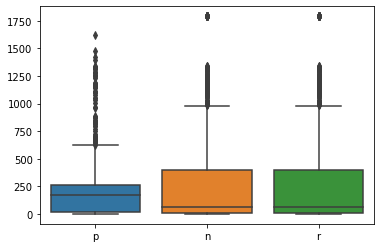

In [13]:
sns.boxplot(y=[positives_snps_occ, negatives_snps_occ, random_snps_occ], x=['p', 'n', 'r'])

In [14]:
df_positives

,id,snp_8_133462953,snp_2_91635413,snp_9_25963828,snp_1_17764169,snp_12_41767967,snp_4_49530811,snp_2_96519717,snp_7_116910447,snp_18_56742728,...,snp_1_143276644,snp_16_9536673,snp_20_25734788,AGE,T2D,sex,mo,fa,mo_t2d,fa_t2d
0,A13186,0,1,0,0,0,0,0,0,0,...,0,0,0,18,0,F,A13125,A13206,0.0,2.0
1,A04177,0,0,0,0,0,1,0,0,0,...,1,0,0,30,0,F,A01243,A04011,1.0,2.0
2,A20059,0,2,0,0,0,1,1,0,0,...,1,0,1,26,0,F,A02236,A20011,0.0,2.0
3,A22024,0,0,0,0,0,0,0,0,0,...,0,0,0,38,0,F,A22063,A22040,0.0,2.0
4,A24012,0,0,0,0,0,0,0,0,0,...,0,0,0,70,0,F,A24154,A24116,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,A01939,0,0,0,0,0,0,0,0,0,...,0,0,0,33,0,M,A01937,A01938,0.0,1.0
1788,834131,0,0,0,0,0,1,0,0,0,...,0,0,0,19,0,M,834129,834132,0.0,2.0
1789,A07058,0,0,0,0,0,0,0,0,0,...,0,0,0,46,1,F,A07038,A07054,2.0,2.0
1790,A16013,0,0,1,1,0,1,1,1,0,...,1,0,1,90,1,M,A16047,A16011,2.0,2.0


In [15]:
df_positives_radomized = df_positives.copy()
for c in df_positives_radomized.columns:
    if 'snp' in c:
        df_positives_radomized[c] = np.random.permutation(df_positives_radomized[c].values)
    

In [16]:
df_positives_radomized_snps = df_positives_radomized[[c for c in df_positives_radomized.columns if 'snp' in c]]

In [17]:
positive_randomized_snps_occ = (df_positives_radomized_snps > 0).values.sum(axis=0)

## Distribuição da contagem de indivíduos com alelos recessivos para os 1000 SNPs de cada conjunto

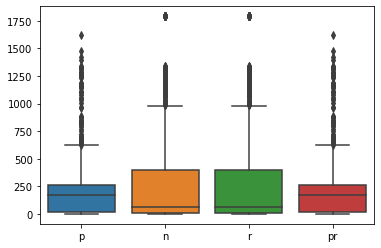

In [18]:
sns.boxplot(y=[positives_snps_occ, negatives_snps_occ,random_snps_occ, positive_randomized_snps_occ], x=['p', 'n', 'r','pr'])

In [33]:
snps_count = pd.DataFrame({'p':positives_snps_occ,'n': negatives_snps_occ, 'r': random_snps_occ, 'pr': positive_randomized_snps_occ})

In [36]:
snps_count

,p,n,r,pr
0,3,11,185,3
1,162,6,8,162
2,303,12,111,303
3,214,7,21,214
4,69,135,510,69
...,...,...,...,...
995,206,487,723,206
996,840,95,16,840
997,492,202,650,492
998,14,1120,5,14


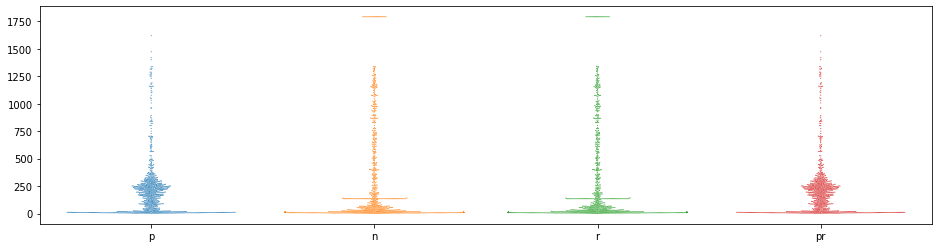

In [45]:
plt.figure(figsize=(16,4))
sns.swarmplot(data=snps_count,size=1)

In [19]:
df_positives

,id,snp_8_133462953,snp_2_91635413,snp_9_25963828,snp_1_17764169,snp_12_41767967,snp_4_49530811,snp_2_96519717,snp_7_116910447,snp_18_56742728,...,snp_1_143276644,snp_16_9536673,snp_20_25734788,AGE,T2D,sex,mo,fa,mo_t2d,fa_t2d
0,A13186,0,1,0,0,0,0,0,0,0,...,0,0,0,18,0,F,A13125,A13206,0.0,2.0
1,A04177,0,0,0,0,0,1,0,0,0,...,1,0,0,30,0,F,A01243,A04011,1.0,2.0
2,A20059,0,2,0,0,0,1,1,0,0,...,1,0,1,26,0,F,A02236,A20011,0.0,2.0
3,A22024,0,0,0,0,0,0,0,0,0,...,0,0,0,38,0,F,A22063,A22040,0.0,2.0
4,A24012,0,0,0,0,0,0,0,0,0,...,0,0,0,70,0,F,A24154,A24116,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,A01939,0,0,0,0,0,0,0,0,0,...,0,0,0,33,0,M,A01937,A01938,0.0,1.0
1788,834131,0,0,0,0,0,1,0,0,0,...,0,0,0,19,0,M,834129,834132,0.0,2.0
1789,A07058,0,0,0,0,0,0,0,0,0,...,0,0,0,46,1,F,A07038,A07054,2.0,2.0
1790,A16013,0,0,1,1,0,1,1,1,0,...,1,0,1,90,1,M,A16047,A16011,2.0,2.0


In [20]:
df_positives_radomized

,id,snp_8_133462953,snp_2_91635413,snp_9_25963828,snp_1_17764169,snp_12_41767967,snp_4_49530811,snp_2_96519717,snp_7_116910447,snp_18_56742728,...,snp_1_143276644,snp_16_9536673,snp_20_25734788,AGE,T2D,sex,mo,fa,mo_t2d,fa_t2d
0,A13186,0,0,0,0,0,0,0,0,0,...,0,0,0,18,0,F,A13125,A13206,0.0,2.0
1,A04177,0,0,0,0,0,1,0,0,0,...,1,0,0,30,0,F,A01243,A04011,1.0,2.0
2,A20059,0,0,0,0,0,0,1,0,0,...,0,0,0,26,0,F,A02236,A20011,0.0,2.0
3,A22024,0,0,0,0,0,0,1,0,0,...,0,0,0,38,0,F,A22063,A22040,0.0,2.0
4,A24012,0,0,0,0,0,0,0,0,0,...,0,0,0,70,0,F,A24154,A24116,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,A01939,0,2,0,0,0,0,0,1,0,...,1,0,0,33,0,M,A01937,A01938,0.0,1.0
1788,834131,0,0,0,0,2,1,0,0,0,...,1,0,0,19,0,M,834129,834132,0.0,2.0
1789,A07058,0,0,0,0,0,1,0,0,0,...,1,0,0,46,1,F,A07038,A07054,2.0,2.0
1790,A16013,0,0,1,0,0,0,1,0,0,...,0,0,0,90,1,M,A16047,A16011,2.0,2.0


In [21]:
df_positives_radomized.to_csv('visits_sp_unique_train_randomized_1_positivo_1000_random_0.csv')

In [25]:
(df_positives_radomized_snps > 0).values.sum(axis=0).shape

(1000,)